# 02 - Environment + classical baselines on the test window

Runs the trading environment under deliberately simple policies on the
2020 -> 2026 SPY test window:

* fixed-action sanity (always +1 / 0 / -1) -- isolates what the env *itself*
  produces under non-adaptive behaviour, and frames the cost model.
* `random_policy_path` -- uniform-random benchmark, the "no information" floor.
* `tabular_q_path` -- tabular Q baseline by Monte Carlo regression on quantile-
  binned features (`mode="mc_regression"`).
* `linear_fqi_path` -- the matched linear analogue, fit by OLS on the same MC
  targets the Bayesian sampler will see in notebook 04.

This notebook is **pre-Bayesian**. The sampler, Thompson decision rule, and
posterior predictive evaluation arrive in notebooks 03-05. The point here is
to lock the comparison scaffolding -- action / position / cumulative-return
plots, transaction-cost intuition -- against a single deterministic seed, so
that when posterior-predictive bands enter the picture they have somewhere
to land. No claim about which baseline "wins" is made; the apples-to-apples
Bayesian-vs-classical comparison lives in notebook 05.

All plotting is delegated to `project.plots`; no inline matplotlib.

In [1]:
import sys
from pathlib import Path

NB_ROOT = Path.cwd().resolve()
SRC = NB_ROOT.parent / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd

from project import baselines, data, env, features, plots
from project.utils import set_seed, ensure_dirs

ensure_dirs()
rng = set_seed()

SEED = 42

## Data, features, train/test split

Pulls SPY from cache (created in notebook 00), builds the four-feature state
vector on the full series, and slices the standard train (1994-2019) and
test (2020-2026) windows. The classical baselines fit on the train window
and evaluate on the test window; `random_policy_path` ignores the train data
entirely. The features object passed into each baseline is *not* dropped of
NaN warmup rows -- the baseline implementations handle alignment internally
via reindex and valid-row masks.

In [2]:
spy = data.load_spy()
splits = data.split_windows(spy)
prices_train = splits["train"]
prices_test = splits["test"]

feat = features.build_features(spy)
feat_train = feat.reindex(prices_train.index)
feat_test = feat.reindex(prices_test.index)

print(f"prices_train : {len(prices_train):>5} rows  "
      f"({prices_train.index.min().date()} -> {prices_train.index.max().date()})")
print(f"prices_test  : {len(prices_test):>5} rows  "
      f"({prices_test.index.min().date()} -> {prices_test.index.max().date()})")
print(f"feat_train   : {feat_train.dropna().shape[0]:>5} rows after warmup")
print(f"feat_test    : {feat_test.dropna().shape[0]:>5} rows after warmup")

prices_train :  6546 rows  (1994-01-03 -> 2019-12-31)
prices_test  :  1589 rows  (2020-01-02 -> 2026-04-29)
feat_train   :  6508 rows after warmup
feat_test    :  1589 rows after warmup


## Fixed-action sanity: what does the env produce under non-adaptive behaviour?

Three trivial "policies" -- always long, always flat, always short -- bracket
the env response. Always-flat earns identically zero reward (a=0 zeros out
both the return term and the cost term). Always-long traces out SPY's
cumulative log return after the 20-day vol-warmup; always-short mirrors it.
Neither rebalances within the test window -- the cost model bites only on
position changes -- so the chart below shows the env's underlying return
path uncluttered by adaptive cost accrual.

This isolates a useful intuition: the cost model only matters once the
policy starts trading. Whatever an active baseline gives up to costs in
the next section is *over and above* the directional return signal here.

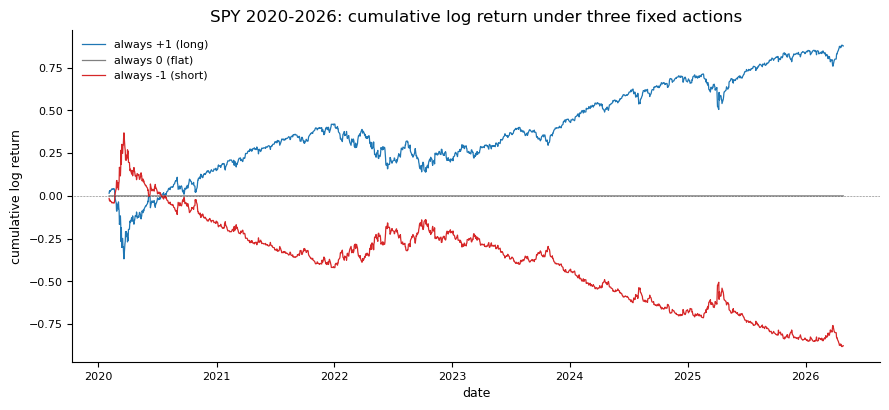

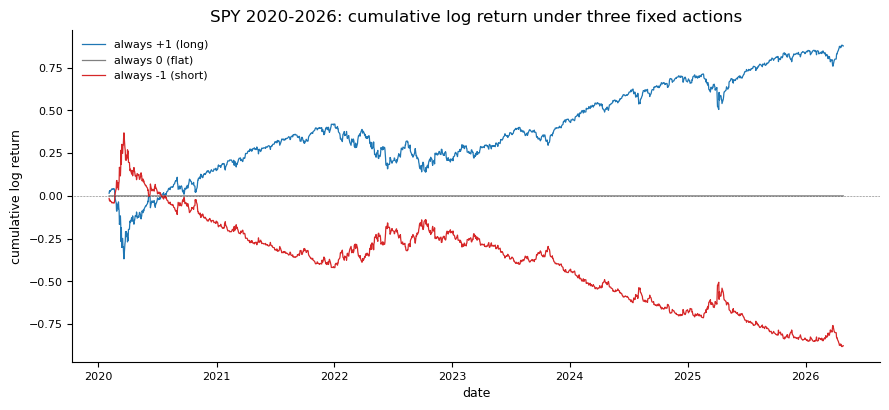

In [3]:
n_test = len(prices_test)
fixed_paths = {}
for name, action_value in [("long_only", 1), ("flat_only", 0), ("short_only", -1)]:
    actions = np.full(n_test, action_value, dtype=int)
    rewards = env.step_reward(prices_test, actions, initial_position=0.0)
    fixed_paths[name] = rewards.cumsum().rename("cum_log_return")

fixed_styles = {
    "long_only":  {"color": plots.DEFAULT_STYLE["color_action_long"],  "linestyle": "-", "label": "always +1 (long)"},
    "flat_only":  {"color": plots.DEFAULT_STYLE["color_action_flat"],  "linestyle": "-", "label": "always 0 (flat)"},
    "short_only": {"color": plots.DEFAULT_STYLE["color_action_short"], "linestyle": "-", "label": "always -1 (short)"},
}
fig, ax = plots.plot_cumulative_return(fixed_paths, style={"policy_styles": fixed_styles})
ax.set_title("SPY 2020-2026: cumulative log return under three fixed actions")
fig

## Classical baselines on the test window

Three single-seed rollouts using only what `project.baselines` exposes today:
uniform-random, tabular MC-regression Q, and linear FQI. Each fits on the
training window and acts greedily on the test window (the random baseline
ignores training entirely). Multi-seed orchestration via
`classical_baseline_distribution` is a 20-seed run that takes minutes; that
lives in notebook 05 (main comparison) so this notebook stays under its
60-second budget.

The cost model now becomes load-bearing: every position change on a
high-vol day pays `c_t = c_0 + lambda * sigma_t^(20)`, which spikes through
2020-Q1 and 2022. A baseline that flips position frequently in a high-vol
regime will look much worse than the same baseline in a calm one, before
any reward-side signal has even arrived.

In [4]:
paths = {
    "random": baselines.random_policy_path(
        prices_test, feat_test, n_actions=3, seed=SEED,
    ),
    "tabular": baselines.tabular_q_path(
        prices_train, feat_train, prices_test, feat_test, seed=SEED,
    ),
    "linear_fqi": baselines.linear_fqi_path(
        prices_train, feat_train, prices_test, feat_test, seed=SEED,
    ),
}

print(f"{'policy':<11} {'final cum log':>14}  {'mean reward':>12}  {'turnover':>9}")
for name, p in paths.items():
    final_cum = float(p["cum_log_return"].dropna().iloc[-1])
    mean_r = float(p["rewards"].dropna().mean())
    turn = float(p["actions"].diff().abs().dropna().mean())
    print(f"{name:<11} {final_cum:>+14.4f}  {mean_r:>+12.5f}  {turn:>9.4f}")

policy       final cum log   mean reward   turnover
random             -7.9397      -0.00507     0.8766
tabular            -3.7141      -0.00237     0.4490
linear_fqi         -0.1425      -0.00009     0.0164


## Action timelines

Three step plots overlaid on a shared axes. Each policy's colour and
linestyle come from `policy_styles`: random is grey, the two classical
baselines share the orange "classical" hue and differ by linestyle (linear
FQI solid, tabular dashed). The action axis is the discrete `{-1, 0, +1}`
set; transitions show *when* each policy moves on the test window.

Overlaying three policies on one axes is visually busy by design. The goal
here is to read off *when* each policy makes its switching decisions, not
*how often*. The action-frequency bar chart and per-policy holdings panels
below cover the dwell-time question.

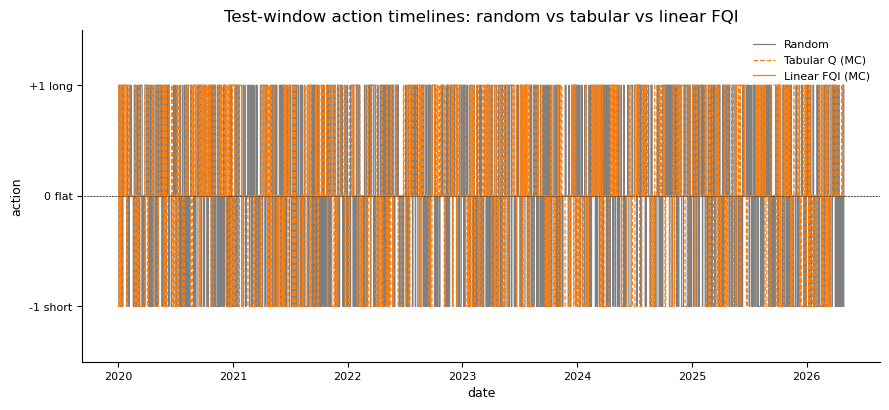

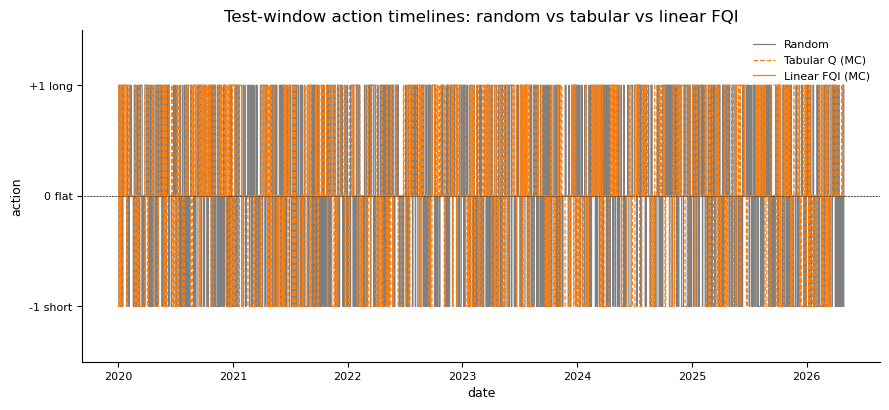

In [5]:
ps = plots.DEFAULT_STYLE["policy_styles"]
fig, ax = plots.plot_action_timeline(
    paths["random"]["actions"], label=ps["random"]["label"], policy="random",
)
plots.plot_action_timeline(
    paths["tabular"]["actions"], label=ps["tabular"]["label"], policy="tabular", ax=ax,
)
plots.plot_action_timeline(
    paths["linear_fqi"]["actions"], label=ps["linear_fqi"]["label"], policy="linear_fqi", ax=ax,
)
ax.set_title("Test-window action timelines: random vs tabular vs linear FQI")
fig

## Cumulative log return overlay

The headline path-level comparison: per-step rewards (action * next-day log
return minus rebalancing cost) accumulated over the test window. Slope
equals mean daily log reward; the gap to zero at any point is the realised
log-return of the strategy net of costs up to that day.

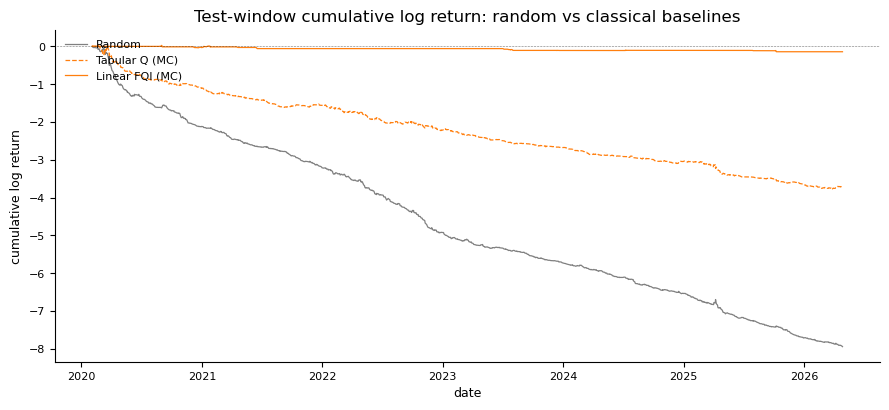

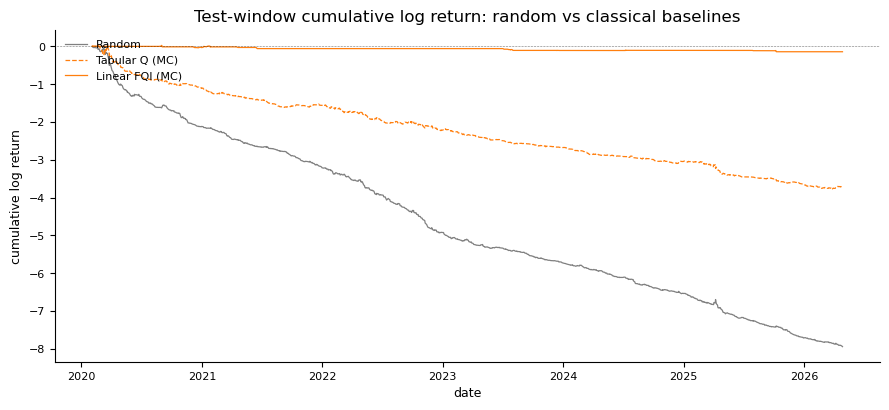

In [6]:
cum = {name: p["cum_log_return"] for name, p in paths.items()}
fig, ax = plots.plot_cumulative_return(cum)
ax.set_title("Test-window cumulative log return: random vs classical baselines")
fig

## Position holdings, per policy

Same data as the action timeline, but laid out one policy per panel. The
filled area below each step plot makes regime-occupancy easier to read --
where each policy spends its time, and how decisively it commits to a
position vs flipping back and forth. The action-timeline overlay above
covers the transition story; this panel covers the dwell story.

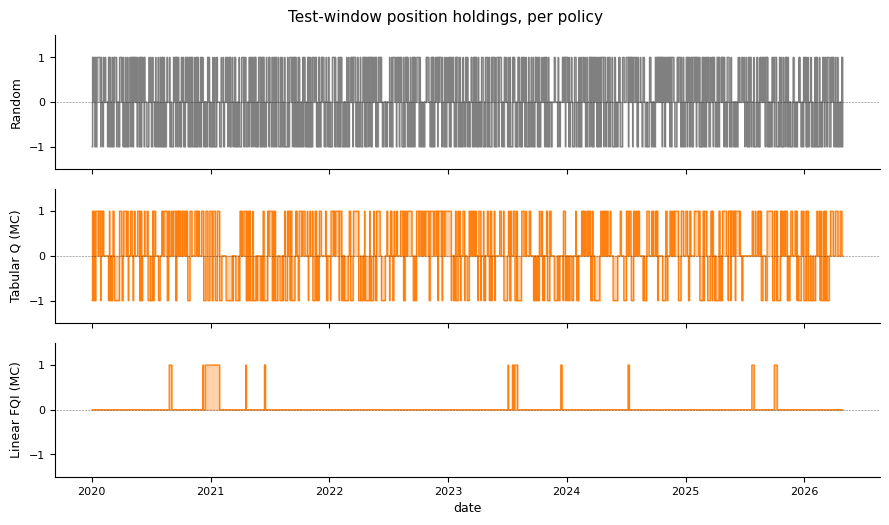

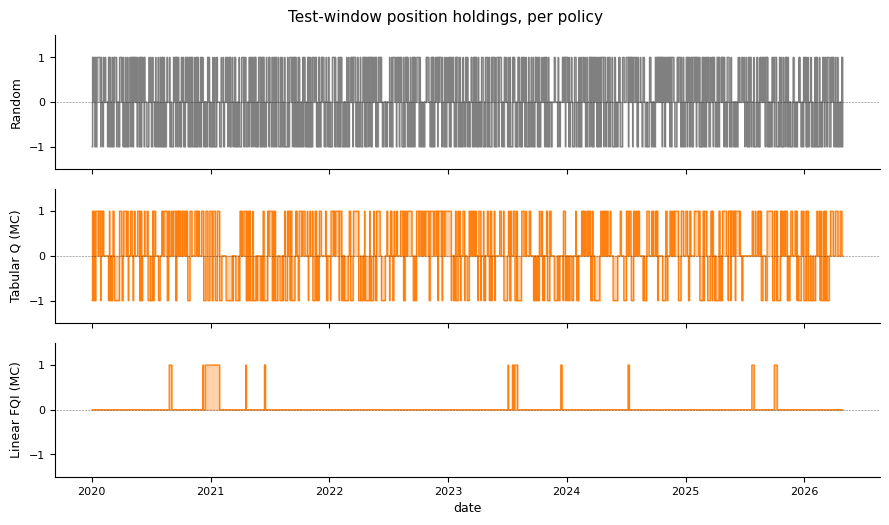

In [7]:
positions = {name: p["positions"] for name, p in paths.items()}
fig, axes = plots.plot_position_holdings(positions)
fig.suptitle("Test-window position holdings, per policy", fontsize=11, y=1.02)
fig

## Action frequency

Fraction of the test window each policy spent in each action label. The
random baseline is approximately uniform by construction (~33% per action).
Tabular Q and linear FQI inherit their action distribution from the
regression's greedy choice on each test-day feature vector; their
distribution will look nothing like uniform if the features carry
actionable signal.

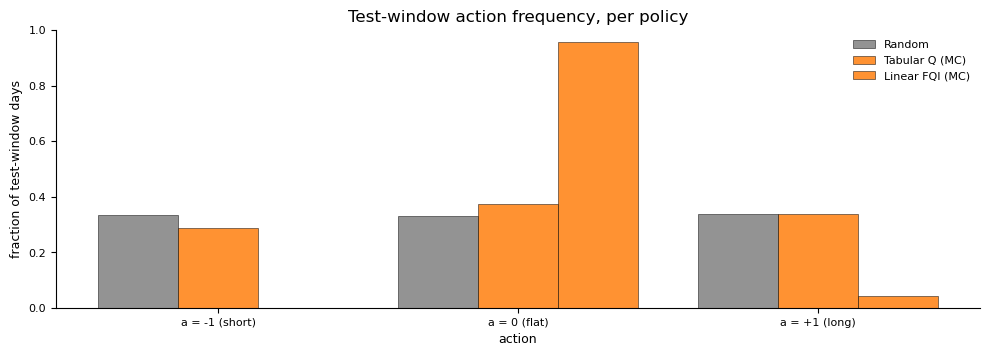

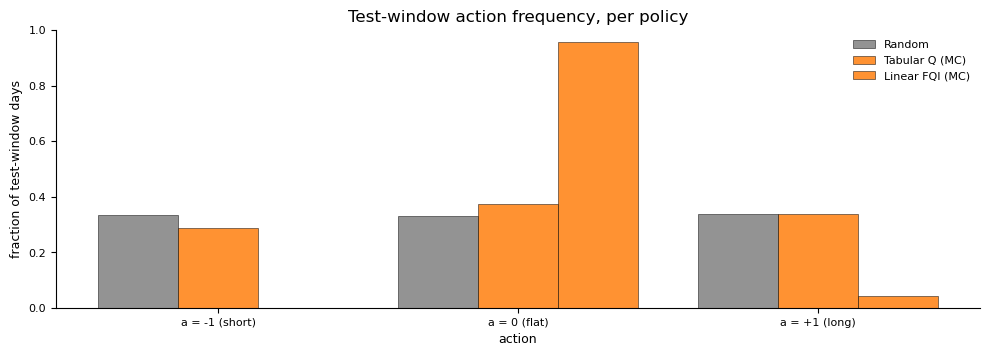

In [8]:
actions_dict = {name: p["actions"] for name, p in paths.items()}
fig, ax = plots.plot_action_frequency(actions_dict)
ax.set_title("Test-window action frequency, per policy")
fig

## Running drawdown

For each policy, the gap between cumulative log return and its running
maximum -- a non-positive function that touches zero at every fresh equity
high. Depth and duration of drawdowns are what turnover-aware investors
actually care about, separate from final return. The 2020-Q1 and 2022
drawdowns dominated the test window for the long-biased fixed actions;
here we see how the active policies sit through them.

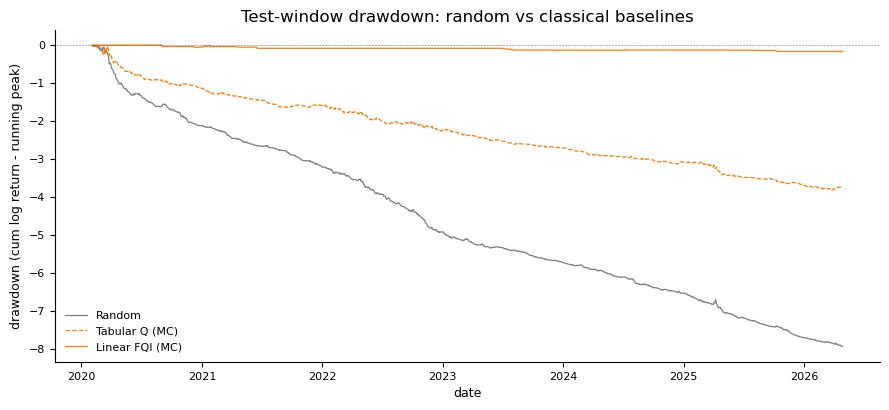

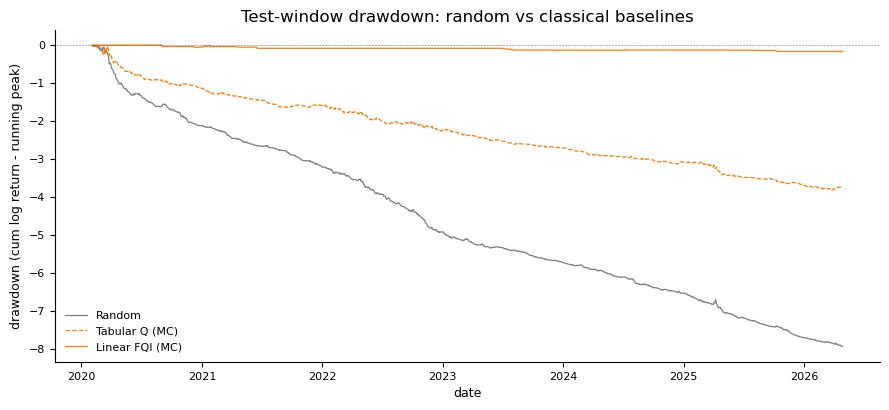

In [9]:
fig, ax = plots.plot_drawdown(cum)
ax.set_title("Test-window drawdown: random vs classical baselines")
fig

## Closing observations

* The fixed-action paths frame the env's behaviour without any adaptive
  decision-making: SPY's return path is the upside, plus a single
  warmup-erased trade cost. None of those policies touch the cost model
  during the test window, so the chart shows the env's underlying return
  signal uncluttered.
* The random baseline is the "no information" floor: with three actions
  drawn uniformly, the policy changes position about 2/3 of the time and
  pays the cost-model penalty on each change without earning any
  directional reward in expectation. A negative final cumulative log
  return is the *expected* outcome and is what we want a benchmark to do.
* Tabular Q and linear FQI both fit the same Monte Carlo return targets
  the Bayesian sampler will see in notebook 04, so any contrast between
  them in later notebooks isolates function-class capacity (a quantile
  binning grid versus the linear span) from inference machinery.
* **Action and position are identical under this env's convention.**
  `R_t = a_t * r_{t+1} - c_t * |a_t - a_{t-1}|` charges cost on the
  *change* in position, which is to say `a_t` semantically *is* the
  target position. The action-timeline and position-holdings panels
  show the same underlying series rendered for two different questions
  (transitions vs dwells); the redundancy is by design and will earn
  its keep in notebook 04 when Thompson actions vary per posterior
  draw and per-policy panels keep each method on a clean axis.
* No "winner" claim here. The Bayesian sampler arrives in notebook 04;
  the apples-to-apples posterior predictive vs multi-seed classical
  comparison lives in notebook 05.

In [10]:
for name, p in paths.items():
    assert set(p.keys()) == {"actions", "positions", "rewards", "cum_log_return"}, (
        f"{name}: unexpected keys {set(p.keys())}"
    )
    assert p["actions"].equals(p["positions"]), (
        f"{name}: action and position diverged (env convention says they shouldn't)"
    )
    assert len(p["actions"]) == len(prices_test)
    assert np.isfinite(float(p["cum_log_return"].dropna().iloc[-1])), (
        f"{name}: final cum_log_return is non-finite"
    )

random_freqs = paths["random"]["actions"].value_counts(normalize=True).to_dict()
for a in (-1, 0, 1):
    assert random_freqs.get(a, 0) > 0.05, (
        f"random policy never produced action {a}: freqs={random_freqs}"
    )

flat_cum_final = float(fixed_paths["flat_only"].dropna().iloc[-1])
assert abs(flat_cum_final) < 1e-12, (
    f"always-flat should accumulate zero reward, got {flat_cum_final}"
)

print("OK")

OK
